# Challenge Telecom X - parte 2
Análisis del perfil de clientes que cancelan servicio.

Lo primero es tener los datos tratados del desafío anterior. por lo que se empezará con el código del Challenge 1.

In [185]:
# Comenzamos importando todas las librerías necesarias.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [186]:
# Nos conectamos a la fuente de datos directa:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
datos = pd.read_json(url)
# Vemos las primeras filas del DataFrame.
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [187]:
# Creamos un df por cada columna que es un JSON anidado.
customer = pd.json_normalize(datos["customer"])
phone = pd.json_normalize(datos["phone"])
internet = pd.json_normalize(datos["internet"])
account = pd.json_normalize(datos["account"])

In [188]:
# De los datos originales, solo queremos conservar la columna "Churn"
# Queremos concatenar las tablas horizontalmente, éso es el eje 1.
df = pd.concat([datos["Churn"], customer, phone, internet, account], axis=1)
df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [189]:
# Convertimos nuestros valores vacíos a NaN para poder trabajar con ellos.
df["Churn"] = df["Churn"].replace('', np.nan)

In [190]:
# Retiramos las filas con valores NaN en la columna "Churn".
df.dropna(subset=["Churn"], inplace=True)

In [191]:
# La celda pasada funcionó, por lo que podemos guardar la variable y volvemos a verificar el DataFrame.
df["Charges.Total"] = df["Charges.Total"].replace(' ', np.nan).astype("float64")

Comenzaremos con la creación de tablas de frecuencia.

In [192]:
# La información principal es saber si cancelaron o no el servicio-
frecuencia_churn = df["Churn"].value_counts()
porcentaje_churn = df["Churn"].value_counts(normalize=True).round(4)* 100
distribucion_churn = pd.DataFrame({"Frecuencia": frecuencia_churn, "Porcentaje": porcentaje_churn})
distribucion_churn.rename_axis("Churn", inplace=True)
distribucion_churn

,Frecuencia,Porcentaje
Churn,,
No,5174,73.46
Yes,1869,26.54


In [193]:
# Hacemos lo mismo para gender
frecuencia_gender = df["gender"].value_counts()
porcentaje_gender = df["gender"].value_counts(normalize=True).round(4)*100
distribucion_gender = pd.DataFrame({"Frecuencia": frecuencia_gender, "Porcentaje": porcentaje_gender})
distribucion_gender

,Frecuencia,Porcentaje
gender,,
Male,3555,50.48
Female,3488,49.52


In [194]:
# Hacemos el crosstab
frecuencia_churn_gender = pd.crosstab(df["Churn"], df["gender"])
frecuencia_churn_gender

gender,Female,Male
Churn,,
No,2549,2625
Yes,939,930


In [195]:
porcentaje_churn_gender = pd.crosstab(df["Churn"], df["gender"], normalize=True).round(4)*100
porcentaje_churn_gender

gender,Female,Male
Churn,,
No,36.19,37.27
Yes,13.33,13.20


Ahora haremos el mismo cruce para las demás variables cualitativas nominales.

In [196]:
porcentaje_churn_seniorcitizen = pd.crosstab(df["Churn"], df["SeniorCitizen"], normalize=True).round(4)*100
porcentaje_churn_seniorcitizen

SeniorCitizen,0,1
Churn,,
No,64.01,9.46
Yes,19.78,6.76


In [197]:
# Partner
porcentaje_churn_partner = pd.crosstab(df["Churn"], df["Partner"], normalize=True).round(4)*100
porcentaje_churn_partner

Partner,No,Yes
Churn,,
No,34.66,38.8
Yes,17.04,9.5


In [198]:
porcentaje_churn_dependents = pd.crosstab(df["Churn"], df["Dependents"], normalize=True).round(4)*100
porcentaje_churn_dependents

Dependents,No,Yes
Churn,,
No,48.13,25.33
Yes,21.91,4.63


In [199]:
porcentaje_churn_phone_service = pd.crosstab(df["Churn"], df["PhoneService"], normalize=True).round(4)*100
porcentaje_churn_phone_service

PhoneService,No,Yes
Churn,,
No,7.27,66.19
Yes,2.41,24.12


In [200]:
porcentaje_churn_multiple_lines = pd.crosstab(df["Churn"], df["MultipleLines"], normalize=True).round(4)*100
porcentaje_churn_multiple_lines

MultipleLines,No,No phone service,Yes
Churn,,,
No,36.08,7.27,30.12
Yes,12.05,2.41,12.07


In [201]:
porcentaje_churn_internet_service = pd.crosstab(df["Churn"], df["InternetService"], normalize=True).round(4)*100
porcentaje_churn_internet_service

InternetService,DSL,Fiber optic,No
Churn,,,
No,27.86,25.54,20.06
Yes,6.52,18.42,1.60


In [202]:
porcentaje_churn_osecurity = pd.crosstab(df["Churn"], df["OnlineSecurity"], normalize=True).round(4)*100
porcentaje_churn_osecurity

OnlineSecurity,No,No internet service,Yes
Churn,,,
No,28.92,20.06,24.48
Yes,20.74,1.60,4.19


In [203]:
porcentaje_churn_obackup = pd.crosstab(df["Churn"], df["OnlineBackup"], normalize=True).round(4)*100
porcentaje_churn_obackup

OnlineBackup,No,No internet service,Yes
Churn,,,
No,26.34,20.06,27.06
Yes,17.51,1.60,7.43


In [204]:
porcentaje_churn_dprotection = pd.crosstab(df["Churn"], df["DeviceProtection"], normalize=True).round(4)*100
porcentaje_churn_dprotection

DeviceProtection,No,No internet service,Yes
Churn,,,
No,26.75,20.06,26.65
Yes,17.19,1.60,7.74


In [205]:
porcentaje_churn_tsupport = pd.crosstab(df["Churn"], df["TechSupport"], normalize=True).round(4)*100
porcentaje_churn_tsupport

TechSupport,No,No internet service,Yes
Churn,,,
No,28.78,20.06,24.62
Yes,20.53,1.60,4.40


In [206]:
porcentaje_churn_streamingtv = pd.crosstab(df["Churn"], df["StreamingTV"], normalize=True).round(4)*100
porcentaje_churn_streamingtv

StreamingTV,No,No internet service,Yes
Churn,,,
No,26.52,20.06,26.88
Yes,13.37,1.60,11.56


In [207]:
porcentaje_churn_streamingmovies = pd.crosstab(df["Churn"], df["StreamingMovies"], normalize=True).round(4)*100
porcentaje_churn_streamingmovies

StreamingMovies,No,No internet service,Yes
Churn,,,
No,26.22,20.06,27.18
Yes,13.32,1.60,11.61


In [208]:
porcentaje_churn_contract = pd.crosstab(df["Churn"], df["Contract"], normalize=True).round(4)*100
porcentaje_churn_contract

Contract,Month-to-month,One year,Two year
Churn,,,
No,31.52,18.56,23.38
Yes,23.50,2.36,0.68


In [209]:
porcentaje_churn_peperless = pd.crosstab(df["Churn"], df["PaperlessBilling"], normalize=True).round(4)*100
porcentaje_churn_peperless

PaperlessBilling,No,Yes
Churn,,
No,34.12,39.34
Yes,6.66,19.88


In [210]:
porcentaje_churn_payment = pd.crosstab(df["Churn"], df["PaymentMethod"], normalize=True).round(4)*100
porcentaje_churn_payment

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Churn,,,,
No,18.26,18.32,18.37,18.51
Yes,3.66,3.29,15.21,4.37


In [211]:
df.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total'],
      dtype='object')

Ahora trabajaremos las variables cuantitativas

In [212]:
# Vemos el tamaño de nuestra base de datos
df.shape

(7043, 20)

Necesitaremos hacer el cálculo de las clases para $n = 7043$

In [213]:
n = df.shape[0]
k = 1 + 10/3 * np.log10(n)
k = int(k)
k

13

In [214]:
frecuencia_sturges_tenure = pd.cut(df["tenure"], bins=k,  include_lowest=True).value_counts().sort_index()
frecuencia_sturges_tenure

tenure
(-0.073, 5.538]     1371
(5.538, 11.077]      698
(11.077, 16.615]     481
(16.615, 22.154]     481
(22.154, 27.692]     409
(27.692, 33.231]     399
(33.231, 38.769]     327
(38.769, 44.308]     371
(44.308, 49.846]     333
(49.846, 55.385]     418
(55.385, 60.923]     348
(60.923, 66.462]     463
(66.462, 72.0]       944
Name: count, dtype: int64

In [215]:
frecuencia_sturges_charges_monthly = pd.cut(df["Charges.Monthly"], bins=k, include_lowest=True).value_counts().sort_index()
frecuencia_sturges_charges_monthly

Charges.Monthly
(18.148999999999997, 25.981]    1576
(25.981, 33.712]                 125
(33.712, 41.442]                 183
(41.442, 49.173]                 325
(49.173, 56.904]                 566
(56.904, 64.635]                 333
(64.635, 72.365]                 558
(72.365, 80.096]                 718
(80.096, 87.827]                 703
(87.827, 95.558]                 727
(95.558, 103.288]                553
(103.288, 111.019]               513
(111.019, 118.75]                163
Name: count, dtype: int64

In [216]:
frecuencia_sturges_charges_total = pd.cut(df["Charges.Total"], bins=k, include_lowest=True).value_counts().sort_index()
frecuencia_sturges_charges_total

Charges.Total
(10.133000000000001, 685.415]    2362
(685.415, 1352.031]              1083
(1352.031, 2018.646]              749
(2018.646, 2685.262]              466
(2685.262, 3351.877]              378
(3351.877, 4018.492]              361
(4018.492, 4685.108]              327
(4685.108, 5351.723]              316
(5351.723, 6018.338]              305
(6018.338, 6684.954]              248
(6684.954, 7351.569]              211
(7351.569, 8018.185]              152
(8018.185, 8684.8]                 74
Name: count, dtype: int64

Ahora haremos lo mismo para tener la tabla por porcentajes.

In [217]:
porcentaje_sturges_charges_monthly = (pd.cut(df["Charges.Monthly"], bins=k, include_lowest=True).value_counts(normalize=True).round(4)*100).sort_index() 
porcentaje_sturges_charges_monthly       

Charges.Monthly
(18.148999999999997, 25.981]    22.38
(25.981, 33.712]                 1.77
(33.712, 41.442]                 2.60
(41.442, 49.173]                 4.61
(49.173, 56.904]                 8.04
(56.904, 64.635]                 4.73
(64.635, 72.365]                 7.92
(72.365, 80.096]                10.19
(80.096, 87.827]                 9.98
(87.827, 95.558]                10.32
(95.558, 103.288]                7.85
(103.288, 111.019]               7.28
(111.019, 118.75]                2.31
Name: proportion, dtype: float64

In [218]:
porcentaje_sturges_charges_total = (pd.cut(df["Charges.Total"], bins=k, include_lowest=True).value_counts(normalize=True).round(4)*100).sort_index()
porcentaje_sturges_charges_total

Charges.Total
(10.133000000000001, 685.415]    33.59
(685.415, 1352.031]              15.40
(1352.031, 2018.646]             10.65
(2018.646, 2685.262]              6.63
(2685.262, 3351.877]              5.38
(3351.877, 4018.492]              5.13
(4018.492, 4685.108]              4.65
(4685.108, 5351.723]              4.49
(5351.723, 6018.338]              4.34
(6018.338, 6684.954]              3.53
(6684.954, 7351.569]              3.00
(7351.569, 8018.185]              2.16
(8018.185, 8684.8]                1.05
Name: proportion, dtype: float64

In [219]:
df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


### Eliminación de columnas irrelevantes.
Las columnas irrelevantes ya fueron eliminadas.

### Encoding
Transformaremos las variables categórigas en numéricas para poder usarlas


In [220]:
# Creamos un diccionario para mapear las variables binarias (Yes/No, etc.)
mapeo = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

In [221]:
# Aplicamos el mapeo a las columnas que tienen únicamente 2 opciones (booleanas)
columnas_binarias = ["Churn", "gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in columnas_binarias:
    df[col] = df[col].map(mapeo)

# Verificamos que las columnas hayas sido modificadas correctamente
df[columnas_binarias].head()

,Churn,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,0,1,1,1,1
1,0,1,0,0,1,0
2,1,1,0,0,1,1
3,1,1,1,0,1,1
4,1,0,1,0,1,1


In [222]:
# Para las variables con más de 2 categorías, usamos One-Hot Encoding
df_final = pd.get_dummies(df, columns=[
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaymentMethod'
])

# Mostramos el resultado transformado
df_final.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,1,1,9,1,1,65.6,593.30,...,True,False,False,False,True,False,False,False,False,True
1,0,1,0,0,0,9,1,0,59.9,542.40,...,False,False,True,True,False,False,False,False,False,True
2,1,1,0,0,0,4,1,1,73.9,280.85,...,True,False,False,True,False,False,False,False,True,False
3,1,1,1,1,0,13,1,1,98.0,1237.85,...,False,False,True,True,False,False,False,False,True,False
4,1,0,1,1,0,3,1,1,83.9,267.40,...,True,False,False,True,False,False,False,False,False,True


In [223]:
# Convertimos todos los True/False (booleanos) a 1/0 (enteros)
df_final = df_final.astype(int)

# Verificamos que ahora todas las columnas sean numéricas
print(df_final.info())
df_final.head()

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Churn                                    7043 non-null   int64  
 1   gender                                   7043 non-null   int64  
 2   SeniorCitizen                            7043 non-null   int64  
 3   Partner                                  7043 non-null   int64  
 4   Dependents                               7043 non-null   int64  
 5   tenure                                   7043 non-null   int64  
 6   PhoneService                             7043 non-null   int64  
 7   PaperlessBilling                         7043 non-null   int64  
 8   Charges.Monthly                          7043 non-null   float64
 9   Charges.Total                            7032 non-null   float64
 10  MultipleLines_No                         7043 non-nul

Dado el error, notamos que :
Charges.Total tiene 7032 valores no nulos de 7043, es decir 11 valors NA. Como solo son 11 filas, vamos a revisarlas.

In [227]:
df[df["Charges.Total"].isna()]

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,0,0,0,1,1,0,0,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,0,Credit card (automatic),56.05,NaN
1775,0,0,0,1,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.00,NaN
1955,0,1,0,0,1,0,1,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,1,Bank transfer (automatic),61.90,NaN
2075,0,1,0,1,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,1,Mailed check,19.70,NaN
2232,0,1,0,0,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.25,NaN
2308,0,1,0,1,1,0,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.35,NaN
2930,0,0,0,1,1,0,1,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,0,Mailed check,73.35,NaN
3134,0,1,0,1,1,0,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.75,NaN
3203,0,0,0,1,1,0,0,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,1,Bank transfer (automatic),52.55,NaN
4169,0,0,0,1,1,0,1,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,0,Mailed check,80.85,NaN


En la columna "tenure" vemos que todos son 0, es decir no tienen antigüedad por lo que son clientes nuevos. Por ello aún no tienen cargos totales registrados. Podemos rellenar sus valors NA con ceros.

In [228]:
# Rellenamos los NA con ceros y volvemos a ejecutar elc código
df_final["Charges.Total"].fillna(0, inplace=True)

df_final = df_final.astype(int)

# Verificamos que ahora todas las columnas sean numéricas
print(df_final.info())
df_final.head()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   Churn                                    7043 non-null   int64
 1   gender                                   7043 non-null   int64
 2   SeniorCitizen                            7043 non-null   int64
 3   Partner                                  7043 non-null   int64
 4   Dependents                               7043 non-null   int64
 5   tenure                                   7043 non-null   int64
 6   PhoneService                             7043 non-null   int64
 7   PaperlessBilling                         7043 non-null   int64
 8   Charges.Monthly                          7043 non-null   int64
 9   Charges.Total                            7043 non-null   int64
 10  MultipleLines_No                         7043 non-null   int64
 11  MultipleL

/tmp/ipykernel_5196/3350658944.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final["Charges.Total"].fillna(0, inplace=True)


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,1,1,9,1,1,65,593,...,1,0,0,0,1,0,0,0,0,1
1,0,1,0,0,0,9,1,0,59,542,...,0,0,1,1,0,0,0,0,0,1
2,1,1,0,0,0,4,1,1,73,280,...,1,0,0,1,0,0,0,0,1,0
3,1,1,1,1,0,13,1,1,98,1237,...,0,0,1,1,0,0,0,0,1,0
4,1,0,1,1,0,3,1,1,83,267,...,1,0,0,1,0,0,0,0,0,1


### Verificación de la proporción de Cancelación

Cantidad de clientes:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporción (en %):
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64%


/tmp/ipykernel_5196/4046105181.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


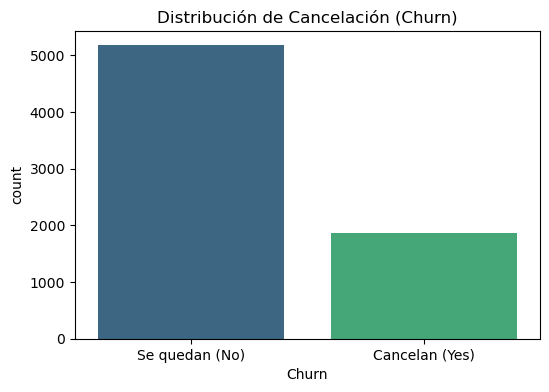

In [232]:
# Contamos cuántos hay de cada uno (usando la columna mapeada 1/0 o la original)
conteo_churn = df_final['Churn'].value_counts()
proporcion_churn = df_final['Churn'].value_counts(normalize=True) * 100

print("Cantidad de clientes:")
print(conteo_churn)
print("\nProporción (en %):")
print(f"{round(proporcion_churn,2)}%")

# Visualización
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribución de Cancelación (Churn)')
plt.xticks([0, 1], ['Se quedan (No)', 'Cancelan (Yes)'])
plt.show()

Existe un desbalance moderado que podría sesgar los modelos en favor de la clase mayoritaria.

### Balanceo

Antes del balanceo: Churn
0    5174
1    1869
Name: count, dtype: int64
Después del balanceo: Churn
0    5174
1    5174
Name: count, dtype: int64


/tmp/ipykernel_5196/337254760.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette='viridis')


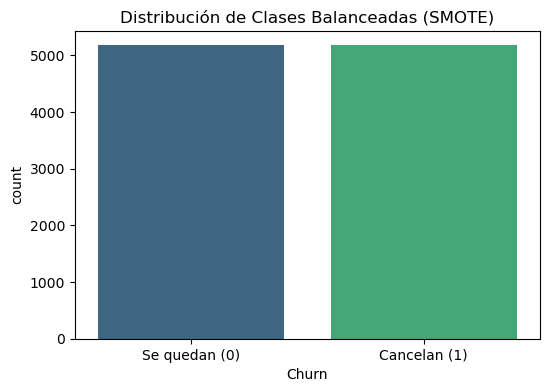

In [233]:
from imblearn.over_sampling import SMOTE

# 1. Separamos nuestras variables: X (todas menos Churn) y y (solo Churn)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# 2. Inicializamos SMOTE
smt = SMOTE(random_state=42)

# 3. Aplicamos el balanceo
# Esto generará nuevos datos para que la clase 0 y la 1 tengan la misma cantidad
X_resampled, y_resampled = smt.fit_resample(X, y)

# 4. Verificamos los nuevos resultados
print(f"Antes del balanceo: {y.value_counts()}")
print(f"Después del balanceo: {y_resampled.value_counts()}")

# Graficamos el resultado
plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled, palette='viridis')
plt.title('Distribución de Clases Balanceadas (SMOTE)')
plt.xticks([0, 1], ['Se quedan (0)', 'Cancelan (1)'])
plt.show()

### Normalización


In [234]:
from sklearn.preprocessing import StandardScaler

# Inicializamos el escalador
scaler = StandardScaler()

# Escalamos los datos balanceados (X_resampled)
X_scaled = scaler.fit_transform(X_resampled)

# X_scaled ahora es un array de Numpy, listo para los modelos sensibles a la escala

### Análisis de correlación

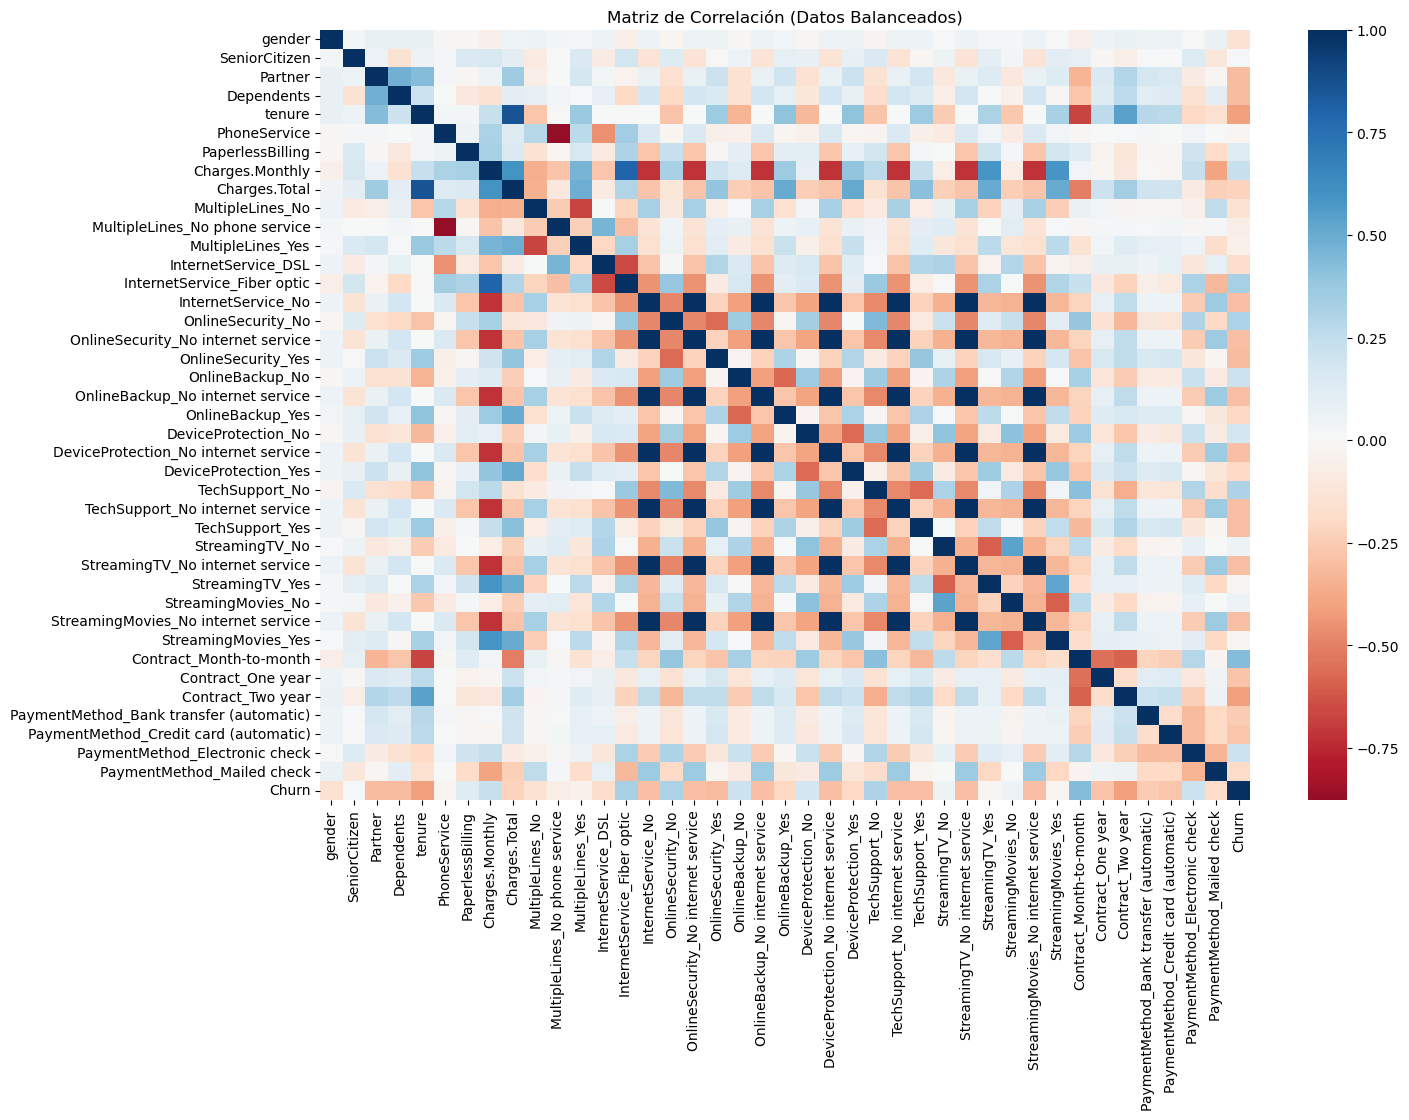

Top 10 variables con mayor correlación positiva con Churn:
Churn                             1.000000
Contract_Month-to-month           0.430004
InternetService_Fiber optic       0.327102
OnlineSecurity_No                 0.316502
TechSupport_No                    0.304993
Charges.Monthly                   0.231153
PaymentMethod_Electronic check    0.209681
OnlineBackup_No                   0.209504
DeviceProtection_No               0.184518
PaperlessBilling                  0.121875
StreamingMovies_No                0.059160
Name: Churn, dtype: float64

Top 10 variables con mayor correlación negativa con Churn:
tenure                                 -0.413314
Contract_Two year                      -0.412860
OnlineSecurity_Yes                     -0.310631
Partner                                -0.310561
Dependents                             -0.309906
TechSupport_Yes                        -0.304655
OnlineSecurity_No internet service     -0.300645
OnlineBackup_No internet service     

In [235]:
# Unimos X_resampled y y_resampled para ver la correlación completa
df_balanceado = pd.DataFrame(X_resampled, columns=X.columns)
df_balanceado['Churn'] = y_resampled

# Calculamos la matriz
corr_matrix = df_balanceado.corr()

# Graficamos el Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu', center=0)
plt.title('Matriz de Correlación (Datos Balanceados)')
plt.show()

# Veamos específicamente qué variables tienen más peso sobre el Churn
print("Top 10 variables con mayor correlación positiva con Churn:")
print(corr_matrix['Churn'].sort_values(ascending=False).head(11))

print("\nTop 10 variables con mayor correlación negativa con Churn:")
print(corr_matrix['Churn'].sort_values(ascending=True).head(10))

Aquí podemos corroborar lo que se vió en el primer proyecto, el tipo de contrato y el tipo de servicio de internet son importantes donde los contratos mensuales y la fibra óptica representan un papel importante en las cancelaciones. Hay que revisar que el servicio de fibra óptica esté dando el servicio esperado por los clientes.

### Análisis dirigido. 
Veamos un análisis dirigido a las 3 variables que considero más importantes "Contract_Month-to-month", InernetService_Fiber optic" y "Charges.Monthly"

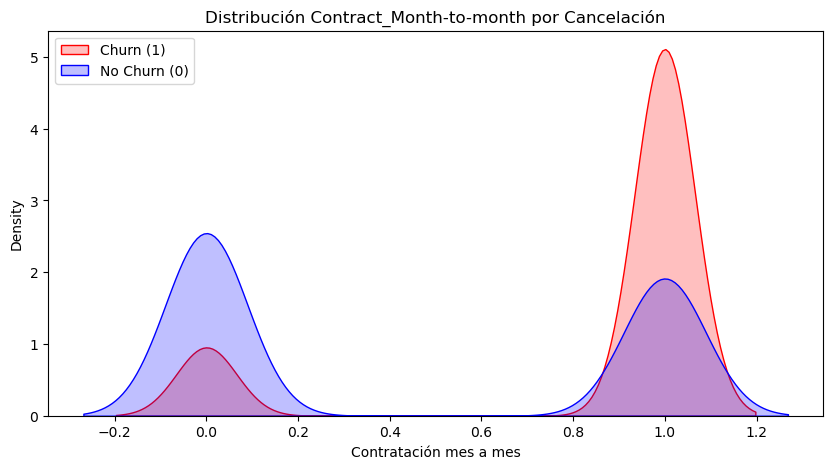

In [238]:
# Visualización de Contract_Month-to-month
plt.figure(figsize=(10, 5))
sns.kdeplot(df_balanceado[df_balanceado['Churn'] == 1]['Contract_Month-to-month'], label='Churn (1)', fill=True, color="red")
sns.kdeplot(df_balanceado[df_balanceado['Churn'] == 0]['Contract_Month-to-month'], label='No Churn (0)', fill=True, color="blue")
plt.title('Distribución Contract_Month-to-month por Cancelación')
plt.xlabel('Contratación mes a mes')
plt.legend()
plt.show()

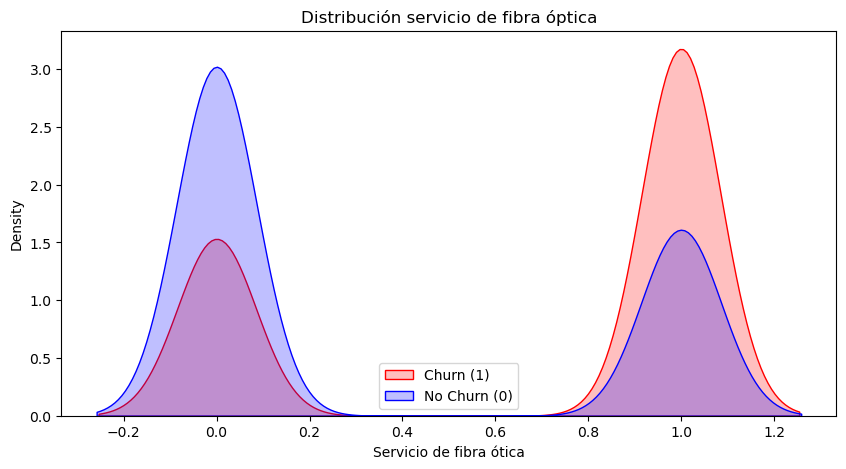

In [240]:
# Visualización de InternetService_Fiber optic
plt.figure(figsize=(10, 5))
sns.kdeplot(df_balanceado[df_balanceado['Churn'] == 1]['InternetService_Fiber optic'], label='Churn (1)', fill=True, color="red")
sns.kdeplot(df_balanceado[df_balanceado['Churn'] == 0]['InternetService_Fiber optic'], label='No Churn (0)', fill=True, color="blue")
plt.title('Distribución servicio de fibra óptica')
plt.xlabel('Servicio de fibra ótica')
plt.legend()
plt.show()

/tmp/ipykernel_5196/931318835.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Charges.Total', data=df_balanceado, palette='Set2')


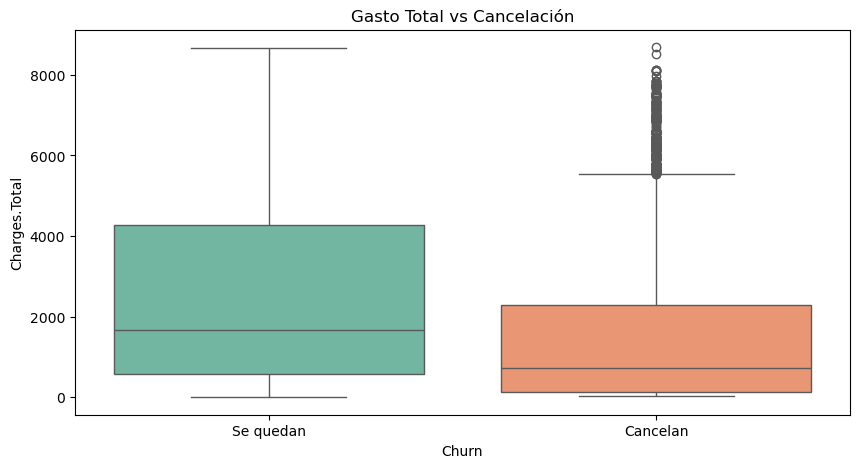

In [243]:
# Visualización de Gastos Totales
plt.figure(figsize=(10, 5))
sns.boxplot(x='Churn', y='Charges.Total', data=df_balanceado, palette='Set2')
plt.title('Gasto Total vs Cancelación')
plt.xticks([0, 1], ['Se quedan', 'Cancelan'])
plt.show()